In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = sns.load_dataset("penguins")
df.to_csv(r"data\penguins.csv", index = False)

In [36]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [37]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [23]:
print(f"Rows: {df.shape[0]} & Columns: {df.shape[1]}") #Rows: 344 & Columns: 7

Rows: 344 & Columns: 7


In [24]:
df[df.duplicated()] #No duplicates found

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


In [25]:
for i in df.columns:
    print(f"{i}: {df[i].isnull().sum()} & {((df[i].isnull().sum())/(len(df))*100).round(2)}%")

species: 0 & 0.0%
island: 0 & 0.0%
bill_length_mm: 2 & 0.58%
bill_depth_mm: 2 & 0.58%
flipper_length_mm: 2 & 0.58%
body_mass_g: 2 & 0.58%
sex: 11 & 3.2%


In [26]:
df.select_dtypes(include=np.number).corr()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


<Axes: >

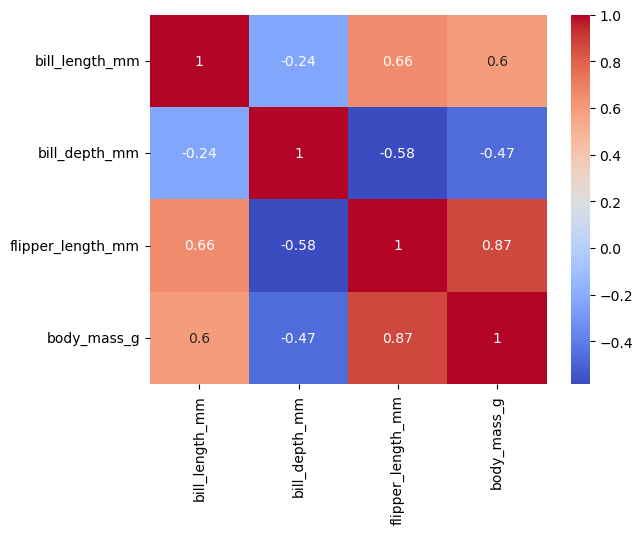

In [27]:
sns.heatmap(data = df.select_dtypes(include=np.number).corr(), annot = True, cmap = "coolwarm")

In [28]:
columns = ["bill_depth_mm", "body_mass_g", "flipper_length_mm"]
for i in columns:
    print(f"Column {i}: Mean: {df.groupby('species')[i].mean()}\n")

Column bill_depth_mm: Mean: species
Adelie       18.346358
Chinstrap    18.420588
Gentoo       14.982114
Name: bill_depth_mm, dtype: float64

Column body_mass_g: Mean: species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64

Column flipper_length_mm: Mean: species
Adelie       189.953642
Chinstrap    195.823529
Gentoo       217.186992
Name: flipper_length_mm, dtype: float64



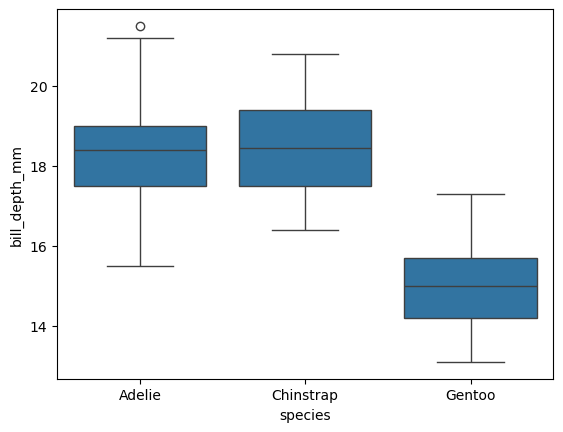

In [29]:
sns.boxplot(data = df, x = 'species', y = 'bill_depth_mm')
plt.show()

In [38]:
for i, j in df.groupby("species"):
    print(f"\nCorrelation matrix for {i}")
    print(j.select_dtypes(include="number").corr())


Correlation matrix for Adelie
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000       0.391492           0.325785   
bill_depth_mm            0.391492       1.000000           0.307620   
flipper_length_mm        0.325785       0.307620           1.000000   
body_mass_g              0.548866       0.576138           0.468202   

                   body_mass_g  
bill_length_mm        0.548866  
bill_depth_mm         0.576138  
flipper_length_mm     0.468202  
body_mass_g           1.000000  

Correlation matrix for Chinstrap
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm           1.000000       0.653536           0.471607   
bill_depth_mm            0.653536       1.000000           0.580143   
flipper_length_mm        0.471607       0.580143           1.000000   
body_mass_g              0.513638       0.604498           0.641559   

                   body_mass_g  
bill_length_mm        0.5

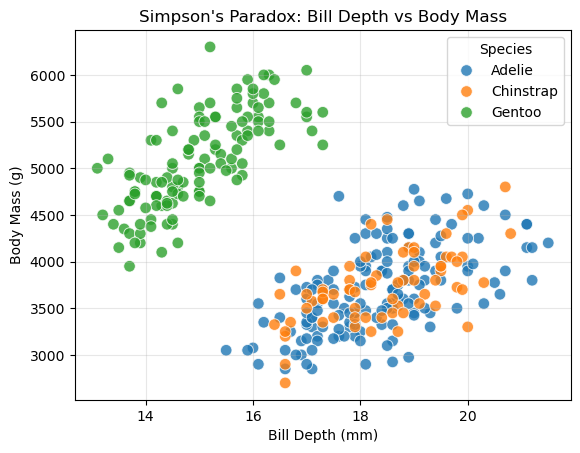

In [42]:
sns.scatterplot(
    data=df,
    x="bill_depth_mm",
    y="body_mass_g",
    hue="species",
    s=70,
    alpha=0.8
)

plt.title("Simpson's Paradox: Bill Depth vs Body Mass")
plt.xlabel("Bill Depth (mm)")
plt.ylabel("Body Mass (g)")
plt.legend(title="Species")
plt.grid(alpha=0.3)

plt.show()

In [33]:
pd.crosstab(df["species"], df["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [34]:
pd.crosstab(df["species"], df["island"], normalize="index")

island,Biscoe,Dream,Torgersen
species,,,
Adelie,0.289474,0.368421,0.342105
Chinstrap,0.000000,1.000000,0.000000
Gentoo,1.000000,0.000000,0.000000


In [35]:
pd.crosstab(df["species"], df["island"], normalize="columns")

island,Biscoe,Dream,Torgersen
species,,,
Adelie,0.261905,0.451613,1.0
Chinstrap,0.000000,0.548387,0.0
Gentoo,0.738095,0.000000,0.0


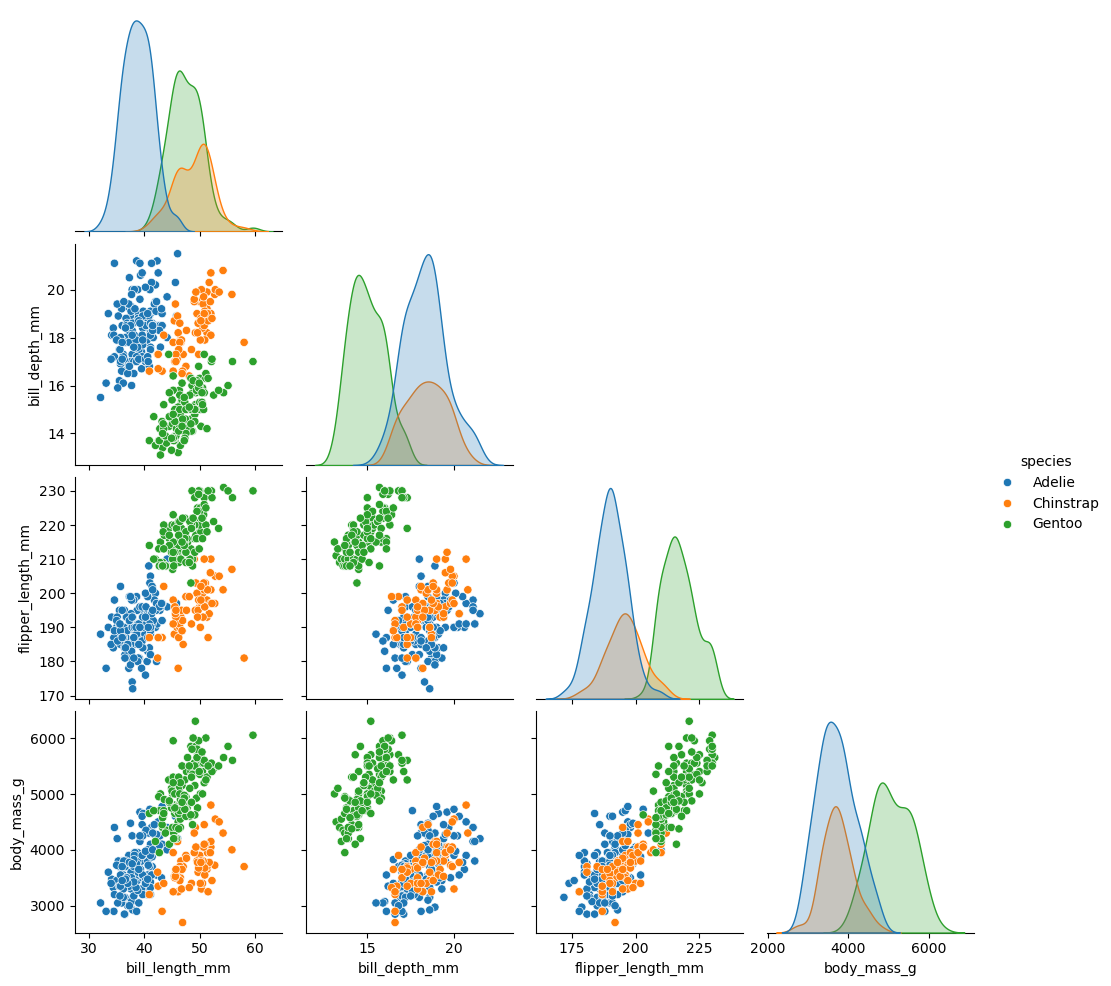

In [44]:
sns.pairplot(
    df,
    hue="species",
    diag_kind="kde",
    corner=True
)

plt.show()